In [1]:
import sys
import os

sys.path.append('/Users/benny/Repos/octagon_analysis')

In [2]:
%load_ext autoreload
%autoreload 2
import globals
import parse_data.prepare_data as prepare_data
import data_extraction.trial_list_filters as trial_list_filters
from matplotlib.patches import Wedge
from matplotlib import pyplot as plt
import data_extraction.get_indices as get_indices
import parse_data.identify_filepaths as identify_filepaths
import globals
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.patches import Polygon
from matplotlib import cm
import math
from parse_data import flip_rotate_trajectories
# import occupancy_and_strategy
from mpl_toolkits.axes_grid1 import make_axes_locatable
import data_strings
import data_extraction.data_saving as data_saving
import plotting.plot_octagon as plot_octagon
import analysis.heatmap_phigh as heatmap_phigh
import pickle
import os

In [5]:
data_folder = '/Volumes/ogma/human_octagon/RAW/risky'

In [6]:
json_filenames_social, json_filenames_solo = identify_filepaths.get_filenames(data_folder)

In [7]:
_, trial_lists_social = prepare_data.prepare_data(data_folder, json_filenames_social, combine=False)
_, trial_lists_solo = prepare_data.prepare_data(data_folder, json_filenames_solo, combine=False)

IntProgress(value=0, max=30)

filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_16-56-08_RH27_TF27_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_2/2025-06-27_18-00-17_KB27_VB27_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250721_1/2025-07-21_09-30-32_VS21_AW21_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250721_2/2025-07-21_12-25-04_UD21_MM21_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250728_1/2025-07-28_09-26-02_CM28_AH28_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250728_2/2025-07-28_10-28-37_AO28_RF28_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250801_1/2025-08-01_11-24-29_IL01_TJ01_Social.json
Loading complete.
Preprocessing complete.
filepath: /Vo

IntProgress(value=0, max=120)

filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_16-45-51_RH27_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_17-15-39_RH27_SecondSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_16-45-33_TF27_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_1/2025-06-27_17-15-18_TF27_SecondSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_2/2025-06-27_17-48-29_KB27_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_2/2025-06-27_18-20-57_KB27_SecondSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/risky/250627_2/2025-06-27_17-48-13_VB27_FirstSolo.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/

In [8]:
json_filenames_first_solo = []
trial_lists_first_solo = []
json_filenames_second_solo = []
trial_lists_second_solo = []

for i in range(0, len(json_filenames_solo), 2):
    json_filenames_first_solo.append(json_filenames_solo[i])
    trial_lists_first_solo.append(trial_lists_solo[i])
    json_filenames_second_solo.append(json_filenames_solo[i+1])
    trial_lists_second_solo.append(trial_lists_solo[i+1])

## Pseudonyms

In [9]:
# assign to pseudonyms

import parse_data.identify_filepaths as identify_filepaths

data_folder = '/Volumes/ogma/human_octagon/RAW/risky'

social_files, ordered_solos = identify_filepaths.get_filenames(data_folder=data_folder)

import re

pseudo_tuples_list = []
experiment_dates_socials = []
for file in social_files:
     # match the session number and the pseudonym string
    match = re.search(r'(\d+_\d)[/\\](\d{4}-\d{2}-\d{2})_(\d{2}-\d{2}-\d{2})_(.*?_.*?)_Social\.json', file)
    if not match:
        print(f"Filename does not match expected pattern: {file}")
    if match:
        session, date, time, pseudonyms = match.groups()
        pseudo_tuples = pseudonyms.split('_')[0::]
        pseudo_tuples_list.append(pseudo_tuples)
        experiment_dates_socials.append((date, pseudo_tuples))

In [10]:
solo_pseudos_arr = np.array(pseudo_tuples_list).ravel()
solo_pseudos = [str(x) for x in solo_pseudos_arr]

In [13]:
import pandas as pd

In [14]:
df = pd.DataFrame(index=solo_pseudos)

# Centrality

In [11]:
import trait_analyses.functions.occupancy_and_strategy as occupancy_and_strategy

In [12]:
mean_central_tendencies_multiple_sessions_socials, central_tendencies_multiple_sessions_socials = occupancy_and_strategy.central_tendency_multiple_sessions(trial_lists=trial_lists_social, num_players=2)
mean_central_tendencies_multiple_sessions_solos, central_tendencies_multiple_sessions_solos = occupancy_and_strategy.central_tendency_multiple_sessions(trial_lists=trial_lists_solo, num_players=1)

In [16]:
mean_central_tendencies_multiple_sessions_first_solos, central_tendencies_multiple_sessions_first = occupancy_and_strategy.central_tendency_multiple_sessions(trial_lists=trial_lists_first_solo, num_players=1)
mean_central_tendencies_multiple_sessions_second_solos, central_tendencies_multiple_sessions_second = occupancy_and_strategy.central_tendency_multiple_sessions(trial_lists=trial_lists_second_solo, num_players=1)

In [17]:
social_central_tendencies_slice_onset_dict = {}
social_ct_values = {}
solo_central_tendencies_slice_onset_dict = {}
solo_ct_values = {}
first_solo_central_tendencies_slice_onset_dict = {}
first_solo_ct_values = {}
second_solo_central_tendencies_slice_onset_dict = {}
second_solo_ct_values = {}

In [18]:
occupancy_dict = {
    'socials': {
        'central_tendency_at_slice_onset': social_central_tendencies_slice_onset_dict,
        'raw_values': social_ct_values,
    },
    'solos': {
        'central_tendency_at_slice_onset': solo_central_tendencies_slice_onset_dict,
        'raw_values': solo_ct_values,
    },
    'first_solos': {
        'central_tendency_at_slice_onset': first_solo_central_tendencies_slice_onset_dict,
        'raw_values': first_solo_ct_values,
    },
    'second_solos': {
        'central_tendency_at_slice_onset': second_solo_central_tendencies_slice_onset_dict,
        'raw_values': second_solo_ct_values,
    }        
}

In [22]:
for i, (player0, player1) in enumerate(pseudo_tuples_list):
    occupancy_dict['socials']['central_tendency_at_slice_onset'][player0] = mean_central_tendencies_multiple_sessions_socials[i][0]
    occupancy_dict['socials']['central_tendency_at_slice_onset'][player1] = mean_central_tendencies_multiple_sessions_socials[i][1]
    occupancy_dict['socials']['raw_values'][player0] = central_tendencies_multiple_sessions_socials[i][0]
    occupancy_dict['socials']['raw_values'][player1] = central_tendencies_multiple_sessions_socials[i][1]

In [24]:
combined_solo_central_tendencies = []

for index in range(0,len(mean_central_tendencies_multiple_sessions_solos),2):
    combined_percentages = np.mean([mean_central_tendencies_multiple_sessions_solos[index] + mean_central_tendencies_multiple_sessions_solos[index + 1]])

    combined_solo_central_tendencies.append(combined_percentages)

In [31]:
for i, pseudonym in enumerate(solo_pseudos):
    player = pseudonym
    occupancy_dict['solos']['central_tendency_at_slice_onset'][player] = combined_solo_central_tendencies[i]

In [32]:
for i, pseudonym in enumerate(solo_pseudos):
    player = pseudonym
    occupancy_dict['first_solos']['central_tendency_at_slice_onset'][player] = mean_central_tendencies_multiple_sessions_first_solos[i]
    occupancy_dict['first_solos']['raw_values'][player] = central_tendencies_multiple_sessions_first[i]

In [33]:
for i, pseudonym in enumerate(solo_pseudos):
    player = pseudonym
    occupancy_dict['second_solos']['central_tendency_at_slice_onset'][player] = mean_central_tendencies_multiple_sessions_second_solos[i]
    occupancy_dict['second_solos']['raw_values'][player] = central_tendencies_multiple_sessions_second[i]

In [34]:
for pseudonym in df.index:
    # SOCIAL
    df.loc[pseudonym, 'slice_onset_centrality_social'] = (
        occupancy_dict['socials']['central_tendency_at_slice_onset'].get(pseudonym, np.nan)
    )
    # SOLO
    df.loc[pseudonym, 'slice_onset_centrality_solo'] = (
        occupancy_dict['solos']['central_tendency_at_slice_onset'].get(pseudonym, np.nan)
    )
    df.loc[pseudonym, 'slice_onset_centrality_first_solo'] = (
        occupancy_dict['first_solos']['central_tendency_at_slice_onset'].get(pseudonym, np.nan)
    )
    df.loc[pseudonym, 'slice_onset_centrality_second_solo'] = (
        occupancy_dict['second_solos']['central_tendency_at_slice_onset'].get(pseudonym, np.nan)
    )

In [37]:
import pickle
with open('p_risky.pkl', 'rb') as fp:
    p_risky_dict = pickle.load(fp)

In [62]:
for pseudonym in df.index:
    # SOCIAL
    df.loc[pseudonym, 'p_risky_social'] = p_risky_dict['social'][str(pseudonym)]
    # FIRST SOLO
    df.loc[pseudonym, 'p_risky_first_solo'] = p_risky_dict['first_solo'][str(pseudonym)]
    # SECOND SOLO
    df.loc[pseudonym, 'p_risky_second_solo'] = p_risky_dict['second_solo'][str(pseudonym)]


In [66]:
from scipy.stats import spearmanr
import seaborn as sns

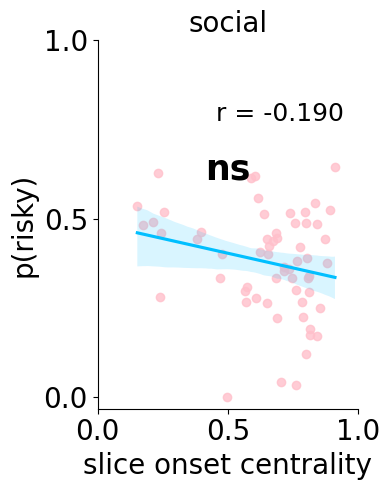

In [69]:
# plotting

# ---------- a) Continuous centrality plots ----------

centrality_cols = {
    "social": "slice_onset_centrality_social",
    #"first solo": "slice_onset_centrality_first_solo",
    #"second solo": "slice_onset_centrality_second_solo"
}

for label, col in centrality_cols.items():

    df_plot = df[[col, "p_risky_social"]].dropna()

    r, p = spearmanr(df_plot[col], df_plot["p_risky_social"])

    plt.figure(figsize=(4, 5))

    sns.regplot(
        data=df_plot,
        x=col,
        y="p_risky_social",
        scatter_kws={"color": "pink", "alpha": 0.8},
        line_kws={"color": "deepskyblue"}
    )

    ax = plt.gca()
    ax.spines[['right', 'top']].set_visible(False)

    plt.grid(False)

    if p < 0.001:
        p_title = "***"
    elif p < 0.01:
        p_title = "**"
    elif p < 0.01:
        p_title = "*"
    else:
        p_title = "ns"

    ax.set_title(f"{label}", fontsize=20)

    ax.text(0.7, 0.8, f"r = {r:.3f}", horizontalalignment='center',
     verticalalignment='center', transform=ax.transAxes, fontsize=18)
    
    ax.text(0.5, 0.65, f"{p_title}", horizontalalignment='center',
     verticalalignment='center', transform=ax.transAxes, fontsize=25, fontweight='bold')
    
    plt.xlabel("slice onset centrality", fontsize=20)
    plt.ylabel("p(risky)", fontsize=20)

    ax.set_yticks(np.arange(0, 1.1, 0.5))
    ax.set_xticks(np.arange(0, 1.1, 0.5))

    ax.tick_params(axis='both', which='major', labelsize=20)

    plt.tight_layout()
    plt.show()

In [ ]:
# compare dyads
# compare performances


,slice_onset_centrality_social,slice_onset_centrality_solo,slice_onset_centrality_first_solo,slice_onset_centrality_second_solo,p_risky_social,p_risky_first_solo,p_risky_second_solo
RH27,0.836403212,0.479460203,0.748696873,0.210223533,0.545454545,0.360000000,0.538461538
TF27,0.637641897,0.432614185,0.282975608,0.582252763,0.512820513,0.800000000,0.157894737
KB27,0.812822717,0.669014847,0.631408922,0.706620773,0.294117647,0.111111111,0.052631579
VB27,0.649854966,0.629450430,0.567885517,0.691015342,0.444444444,0.166666667,0.000000000
VS21,0.572867440,0.475257756,0.316101716,0.634413796,0.307692308,0.666666667,0.117647059
AW21,0.760781563,0.669838732,0.585295906,0.754381559,0.035087719,0.142857143,0.000000000
UD21,0.760506716,0.406561847,0.576828147,0.236295547,0.300000000,0.583333333,0.466666667
MM21,0.814149369,0.795876064,0.789660218,0.802091910,0.191489362,0.250000000,0.083333333
CM28,0.757974543,0.765251595,0.739350030,0.791153160,0.488888889,0.454545455,0.187500000
AH28,0.684937344,0.557332417,0.539317723,0.575347111,0.333333333,0.470588235,0.263157895
